# Neural Models: MLP and LSTM

This notebook documents the neural-network models used in the project.

The notebook covers:

1. motivation for testing neural models  
2. MLP results with `daily` and `daily_ohlcv` feature sources  
3. LSTM results with sequence inputs  
4. training diagnostics and loss curves  
5. prediction and portfolio performance  
6. interpretation of why neural models did not outperform the final Random Forest model  

The objective is to show that neural approaches were evaluated carefully, including training diagnostics, even though they did not become the final selected model.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
    plot_loss_curve,
)

In [3]:
NOTEBOOK_NAME = "notebook07"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook07


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> pd.DataFrame:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")
    return df


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Why test neural models?

Neural models were considered because they can potentially capture nonlinear structure that simpler tabular models may miss.

Two neural approaches were explored:

- **MLP**, as a feed-forward nonlinear benchmark using engineered tabular features  
- **LSTM**, as a sequence model using rolling daily input windows  

This notebook evaluates whether those models improved return prediction or stock ranking enough to justify their additional complexity.

In [5]:
mlp_dirs = {
    "MLP daily": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily",
    "MLP daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily_ohlcv",
}

lstm_dir = PROJECT_ROOT / "experiments" / "results" / "exp06_lstm_daily"

mlp_dirs, lstm_dir

({'MLP daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp05_nn_mlp_daily'),
  'MLP daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp05_nn_mlp_daily_ohlcv')},
 WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp06_lstm_daily'))

In [6]:
for name, nn_dir in mlp_dirs.items():
    print(f"\n{name}")
    print("dir:", nn_dir)
    for fn in [
        "prediction_metrics.json",
        "metrics_train.json",
        "metrics_test_2025.json",
        "metrics_train_with_costs.json",
        "metrics_test_2025_with_costs.json",
        "equity_train.csv",
        "equity_test_2025.csv",
        "training_history.json",
    ]:
        print(f"{fn}: {(nn_dir / fn).exists()}")

print("\nLSTM")
print("dir:", lstm_dir)
for fn in [
    "prediction_metrics.json",
    "metrics_train.json",
    "metrics_test_2025.json",
    "metrics_train_with_costs.json",
    "metrics_test_2025_with_costs.json",
    "equity_train.csv",
    "equity_test_2025.csv",
    "training_history.json",
    "loss_curve.png",
    "pred_vs_actual_train.png",
    "pred_vs_actual_test_2025.png",
    "predictions_train.csv",
    "predictions_test_2025.csv",
]:
    print(f"{fn}: {(lstm_dir / fn).exists()}")


MLP daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp05_nn_mlp_daily
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
training_history.json: True

MLP daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp05_nn_mlp_daily_ohlcv
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
training_history.json: True

LSTM
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp06_lstm_daily
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_cost

In [7]:
def load_nn_experiment(exp_dir: Path) -> dict:
    with open(exp_dir / "prediction_metrics.json", "r") as f:
        prediction_metrics = json.load(f)

    with open(exp_dir / "metrics_train.json", "r") as f:
        metrics_train = json.load(f)

    with open(exp_dir / "metrics_test_2025.json", "r") as f:
        metrics_test = json.load(f)

    with open(exp_dir / "metrics_train_with_costs.json", "r") as f:
        metrics_train_costs = json.load(f)

    with open(exp_dir / "metrics_test_2025_with_costs.json", "r") as f:
        metrics_test_costs = json.load(f)

    equity_train = pd.read_csv(exp_dir / "equity_train.csv", index_col=0).squeeze("columns")
    equity_test = pd.read_csv(exp_dir / "equity_test_2025.csv", index_col=0).squeeze("columns")

    equity_train.index = pd.to_datetime(equity_train.index)
    equity_test.index = pd.to_datetime(equity_test.index)

    history = None
    if (exp_dir / "training_history.json").exists():
        with open(exp_dir / "training_history.json", "r") as f:
            history = json.load(f)

    return {
        "prediction_metrics": prediction_metrics,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_train_costs": metrics_train_costs,
        "metrics_test_costs": metrics_test_costs,
        "equity_train": equity_train,
        "equity_test": equity_test,
        "history": history,
    }

In [8]:
mlp_results = {name: load_nn_experiment(path) for name, path in mlp_dirs.items()}
lstm_results = load_nn_experiment(lstm_dir)

mlp_results.keys(), lstm_results.keys()

(dict_keys(['MLP daily', 'MLP daily_ohlcv']),
 dict_keys(['prediction_metrics', 'metrics_train', 'metrics_test', 'metrics_train_costs', 'metrics_test_costs', 'equity_train', 'equity_test', 'history']))

In [9]:
nn_setup = save_table(
    pd.DataFrame(
        {
            "model_variant": ["MLP daily", "MLP daily_ohlcv", "LSTM"],
            "input_structure": [
                "tabular engineered features",
                "tabular engineered features + OHLCV",
                "sequence input windows",
            ],
            "feature_source": ["daily", "daily_ohlcv", "sequence dataset"],
            "model_family": ["Neural network", "Neural network", "Neural network"],
        }
    ),
    "nn_setup_summary.csv",
    index=False,
)
nn_setup

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\nn_setup_summary.csv


,model_variant,input_structure,feature_source,model_family
0,MLP daily,tabular engineered features,daily,Neural network
1,MLP daily_ohlcv,tabular engineered features + OHLCV,daily_ohlcv,Neural network
2,LSTM,sequence input windows,sequence dataset,Neural network


## 2. MLP models

The MLP experiments provide a neural benchmark using tabular engineered features.

The two MLP variants differ only in feature source:

- `daily`
- `daily_ohlcv`

In [10]:
prediction_rows = []

for model_name, res in mlp_results.items():
    pm = res["prediction_metrics"]

    prediction_rows.append(
        {
            "model": model_name,
            "split": "train_2015_2024",
            "MAE": pm["train"]["regression"]["MAE"],
            "RMSE": pm["train"]["regression"]["RMSE"],
            "R2": pm["train"]["regression"]["R2"],
            "Directional_Accuracy": pm["train"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["train"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["train"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["train"]["ranking"]["Months_evaluated"],
        }
    )

    prediction_rows.append(
        {
            "model": model_name,
            "split": "test_2025",
            "MAE": pm["test_2025"]["regression"]["MAE"],
            "RMSE": pm["test_2025"]["regression"]["RMSE"],
            "R2": pm["test_2025"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025"]["ranking"]["Months_evaluated"],
        }
    )

mlp_prediction_comparison = save_table(
    pd.DataFrame(prediction_rows),
    "mlp_prediction_metrics_comparison.csv",
    index=False,
)
mlp_prediction_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\mlp_prediction_metrics_comparison.csv


,model,split,MAE,RMSE,R2,Directional_Accuracy,SpearmanRankCorr_mean,TopKHitRate_mean,Months_evaluated
0,MLP daily,train_2015_2024,0.057792,0.078028,0.087859,0.555385,0.075078,0.283921,109
1,MLP daily,test_2025,0.054951,0.074401,-0.010457,0.548828,0.081893,0.306220,11
2,MLP daily_ohlcv,train_2015_2024,0.057647,0.077679,0.093237,0.547619,0.082864,0.270591,109
3,MLP daily_ohlcv,test_2025,0.054951,0.074368,-0.009555,0.572266,-0.042016,0.248804,11


In [11]:
strategy_rows = []

for model_name, res in mlp_results.items():
    strategy_rows.append({"model": model_name, "split": "train_2015_2024", **res["metrics_train"]})
    strategy_rows.append({"model": model_name, "split": "test_2025", **res["metrics_test"]})

mlp_strategy_comparison = save_table(
    pd.DataFrame(strategy_rows),
    "mlp_strategy_metrics_comparison.csv",
    index=False,
)
mlp_strategy_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\mlp_strategy_metrics_comparison.csv


,model,split,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,MLP daily,train_2015_2024,4.557908,0.187110,0.197905,-0.229045,0.965156,0.533028,0.550000,0.900000
1,MLP daily,test_2025,0.290920,0.290920,0.135754,-0.043890,1.961135,0.449761,0.473684,0.631579
2,MLP daily_ohlcv,train_2015_2024,4.566088,0.187285,0.187641,-0.222204,1.008588,0.615596,0.600000,0.900000
3,MLP daily_ohlcv,test_2025,0.141031,0.141031,0.140191,-0.079659,1.009288,0.550239,0.578947,0.736842


### MLP training diagnostics

Loss curves provide visibility into the fitting process for the MLP variants.

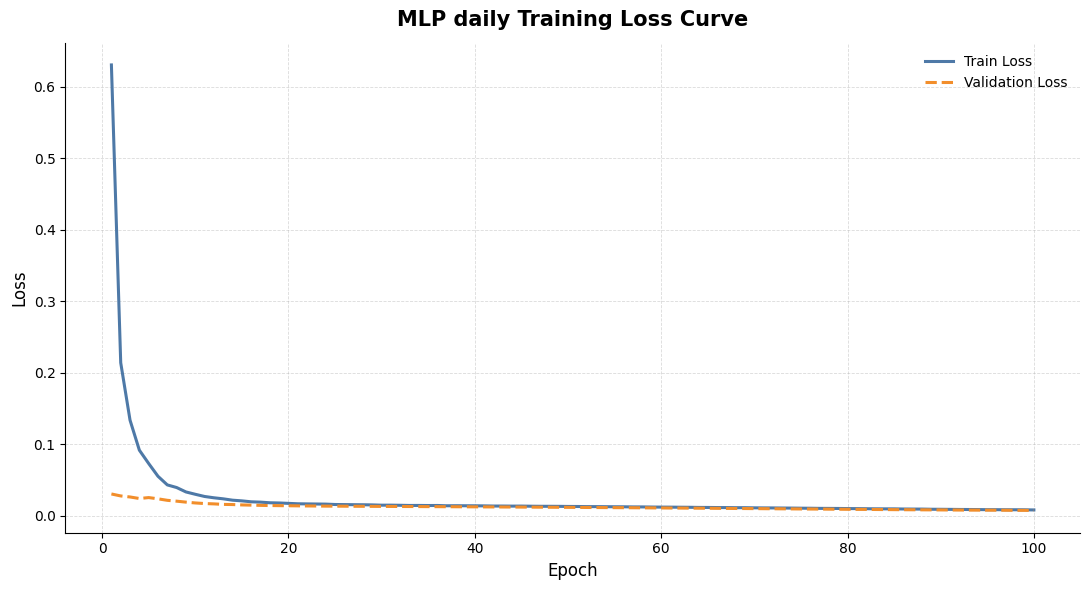

In [12]:
mlp_daily_history = mlp_results["MLP daily"]["history"]

if mlp_daily_history is not None:
    plot_loss_curve(
        mlp_daily_history,
        title="MLP daily Training Loss Curve",
        save_path=fig_path("mlp_daily_loss_curve.png"),
        show=True,
    )
else:
    print("No training history found for MLP daily.")

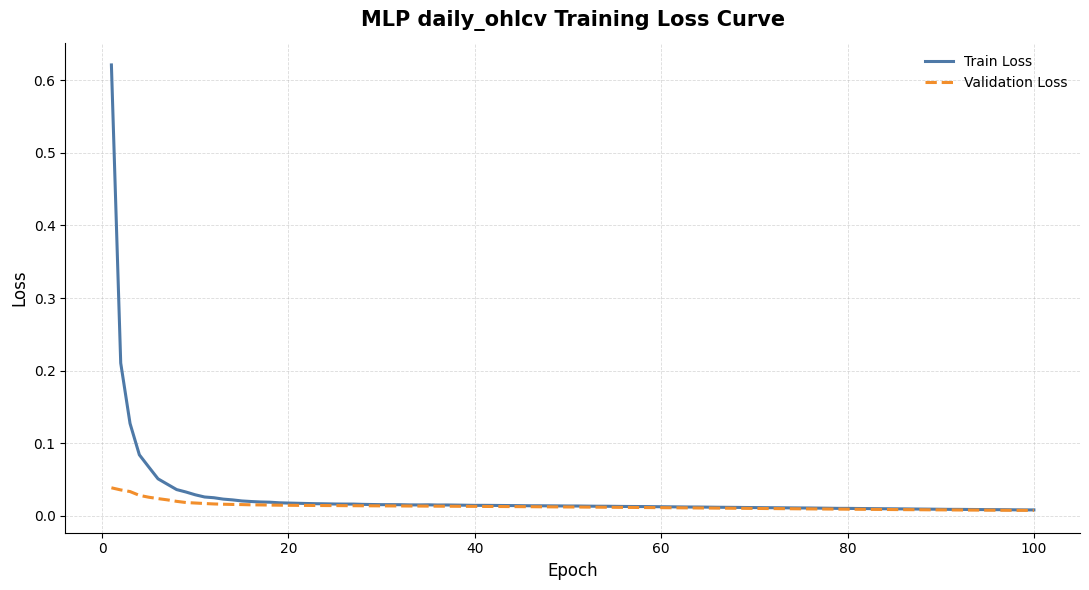

In [13]:
mlp_ohlcv_history = mlp_results["MLP daily_ohlcv"]["history"]

if mlp_ohlcv_history is not None:
    plot_loss_curve(
        mlp_ohlcv_history,
        title="MLP daily_ohlcv Training Loss Curve",
        save_path=fig_path("mlp_daily_ohlcv_loss_curve.png"),
        show=True,
    )
else:
    print("No training history found for MLP daily_ohlcv.")

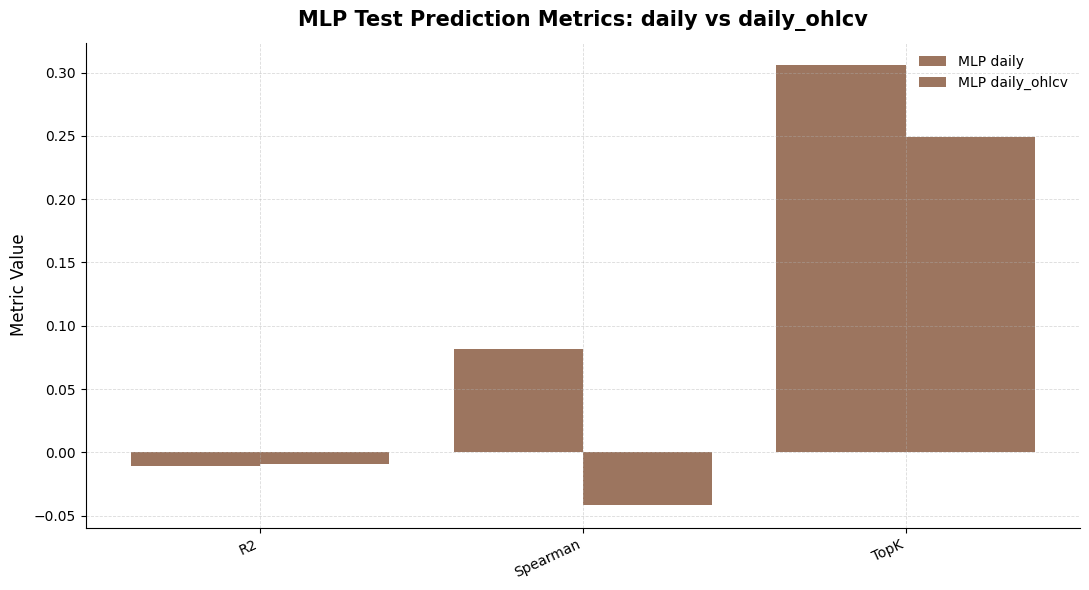

In [14]:
mlp_test_pred = mlp_prediction_comparison[mlp_prediction_comparison["split"] == "test_2025"].set_index("model")

mlp_metric_plot_df = pd.DataFrame(
    {
        "R2": mlp_test_pred["R2"],
        "Spearman": mlp_test_pred["SpearmanRankCorr_mean"],
        "TopK": mlp_test_pred["TopKHitRate_mean"],
    }
).T

plot_grouped_metric_bars(
    metric_df=mlp_metric_plot_df,
    title="MLP Test Prediction Metrics: daily vs daily_ohlcv",
    ylabel="Metric Value",
    color_map={
        "MLP daily": get_model_color("mlp"),
        "MLP daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("mlp_test_prediction_metric_comparison.png"),
    show=True,
)

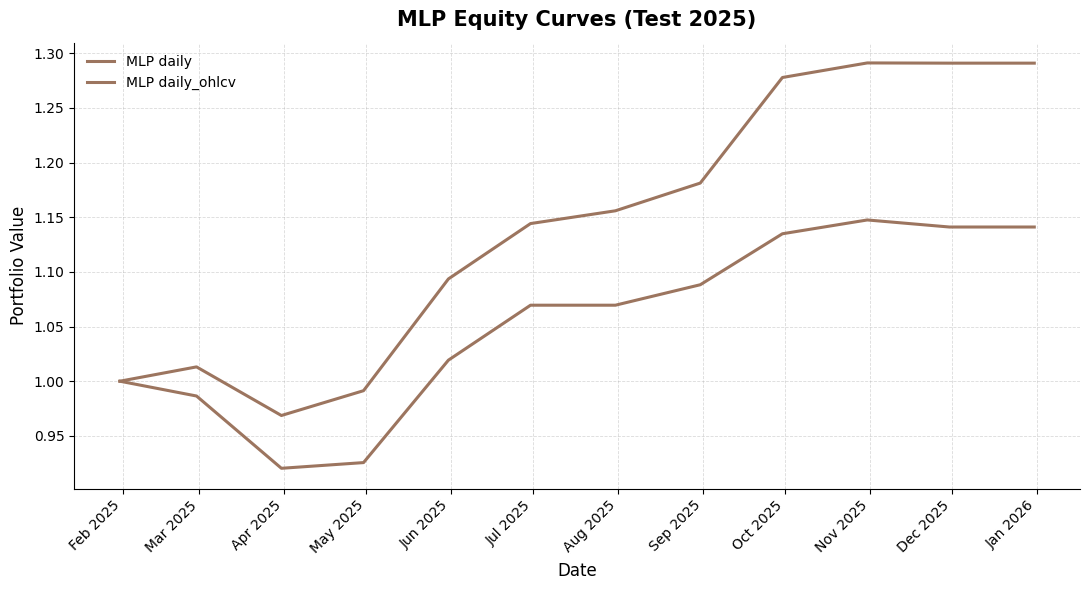

In [15]:
plot_multi_series(
    series_map={
        "MLP daily": mlp_results["MLP daily"]["equity_test"],
        "MLP daily_ohlcv": mlp_results["MLP daily_ohlcv"]["equity_test"],
    },
    title="MLP Equity Curves (Test 2025)",
    ylabel="Portfolio Value",
    color_map={
        "MLP daily": get_model_color("mlp"),
        "MLP daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("mlp_equity_test_comparison.png"),
    show=True,
)

## 3. LSTM model

The LSTM experiment differs from the MLP models because it uses a sequence-based dataset rather than a tabular feature matrix.

This makes it a separate model class rather than a direct daily-vs-daily_ohlcv comparison.

In [16]:
lstm_pm = lstm_results["prediction_metrics"]

lstm_prediction_summary = save_table(
    pd.DataFrame(
        {
            "metric": [
                "MAE",
                "RMSE",
                "R2",
                "Directional_Accuracy",
                "SpearmanRankCorr_mean",
                "TopKHitRate_mean",
                "Months_evaluated",
            ],
            "train_2015_2024": [
                lstm_pm["train"]["regression"]["MAE"],
                lstm_pm["train"]["regression"]["RMSE"],
                lstm_pm["train"]["regression"]["R2"],
                lstm_pm["train"]["regression"]["Directional_Accuracy"],
                lstm_pm["train"]["ranking"]["SpearmanRankCorr_mean"],
                lstm_pm["train"]["ranking"]["TopKHitRate_mean"],
                lstm_pm["train"]["ranking"]["Months_evaluated"],
            ],
            "test_2025": [
                lstm_pm["test_2025"]["regression"]["MAE"],
                lstm_pm["test_2025"]["regression"]["RMSE"],
                lstm_pm["test_2025"]["regression"]["R2"],
                lstm_pm["test_2025"]["regression"]["Directional_Accuracy"],
                lstm_pm["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
                lstm_pm["test_2025"]["ranking"]["TopKHitRate_mean"],
                lstm_pm["test_2025"]["ranking"]["Months_evaluated"],
            ],
        }
    ),
    "lstm_prediction_summary.csv",
    index=False,
)
lstm_prediction_summary

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\lstm_prediction_summary.csv


,metric,train_2015_2024,test_2025
0,MAE,0.057904,0.054757
1,RMSE,0.079342,0.074340
2,R2,0.061683,-0.001352
3,Directional_Accuracy,0.555180,0.551485
4,SpearmanRankCorr_mean,-0.001254,0.021652
5,TopKHitRate_mean,0.205130,0.196704
6,Months_evaluated,112.000000,11.000000


In [17]:
lstm_strategy_summary = save_table(
    pd.DataFrame(
        {
            "metric": list(lstm_results["metrics_train"].keys()),
            "train_2015_2024": [lstm_results["metrics_train"][k] for k in lstm_results["metrics_train"].keys()],
            "test_2025": [lstm_results["metrics_test"][k] for k in lstm_results["metrics_train"].keys()],
        }
    ),
    "lstm_strategy_summary.csv",
    index=False,
)
lstm_strategy_summary

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\lstm_strategy_summary.csv


,metric,train_2015_2024,test_2025
0,cumulative_return,1.059343,0.169316
1,annualized_return,0.074912,0.169316
2,annualized_volatility,0.146106,0.088544
3,max_drawdown,-0.234130,-0.039112
4,sharpe_ratio,0.568427,1.818267
5,avg_turnover,0.715625,0.672727
6,median_turnover,0.750000,0.700000
7,max_turnover,1.000000,0.900000


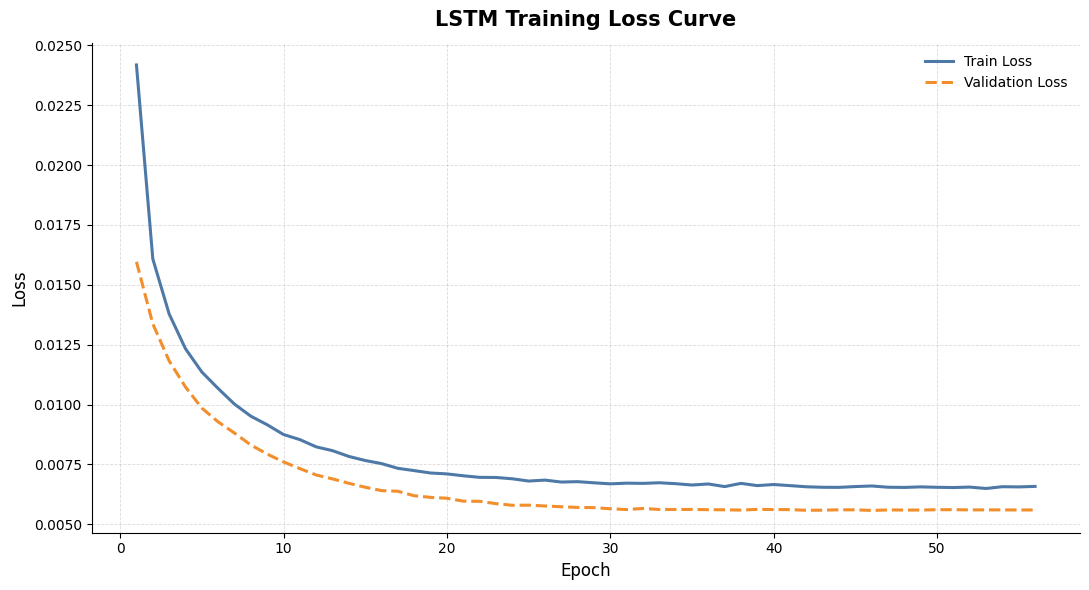

In [18]:
lstm_history = lstm_results["history"]

if lstm_history is not None:
    plot_loss_curve(
        lstm_history,
        title="LSTM Training Loss Curve",
        save_path=fig_path("lstm_loss_curve_from_history.png"),
        show=True,
    )
else:
    print("No training history found for LSTM.")

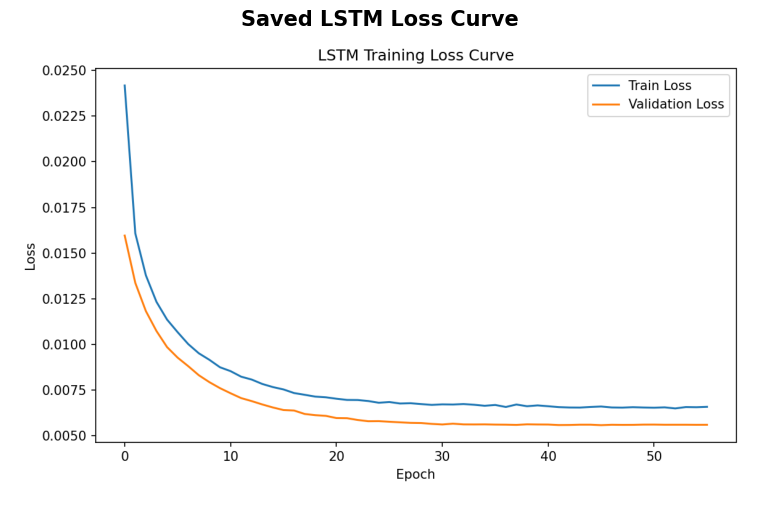

In [19]:
lstm_loss_curve_file = lstm_dir / "loss_curve.png"

if lstm_loss_curve_file.exists():
    img = Image.open(lstm_loss_curve_file)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Saved LSTM Loss Curve", fontsize=STYLE.title_size, fontweight="bold")
    plt.show()
else:
    print("No saved loss_curve.png found for LSTM.")

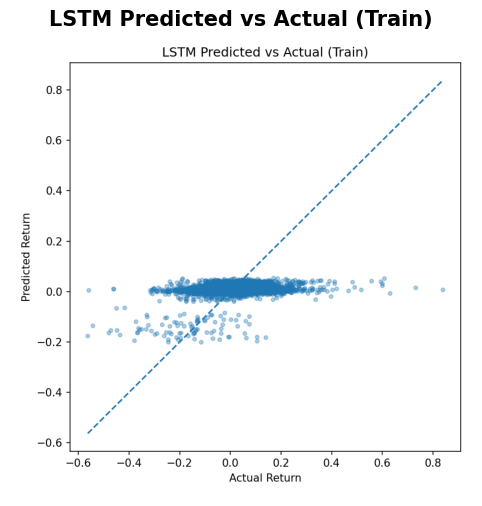

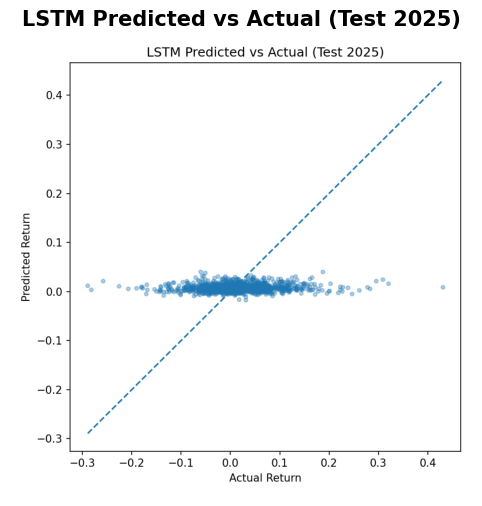

In [20]:
for fn, title in [
    ("pred_vs_actual_train.png", "LSTM Predicted vs Actual (Train)"),
    ("pred_vs_actual_test_2025.png", "LSTM Predicted vs Actual (Test 2025)"),
]:
    img_path = lstm_dir / fn
    if img_path.exists():
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=STYLE.title_size, fontweight="bold")
        plt.show()
    else:
        print(f"{fn} not found.")

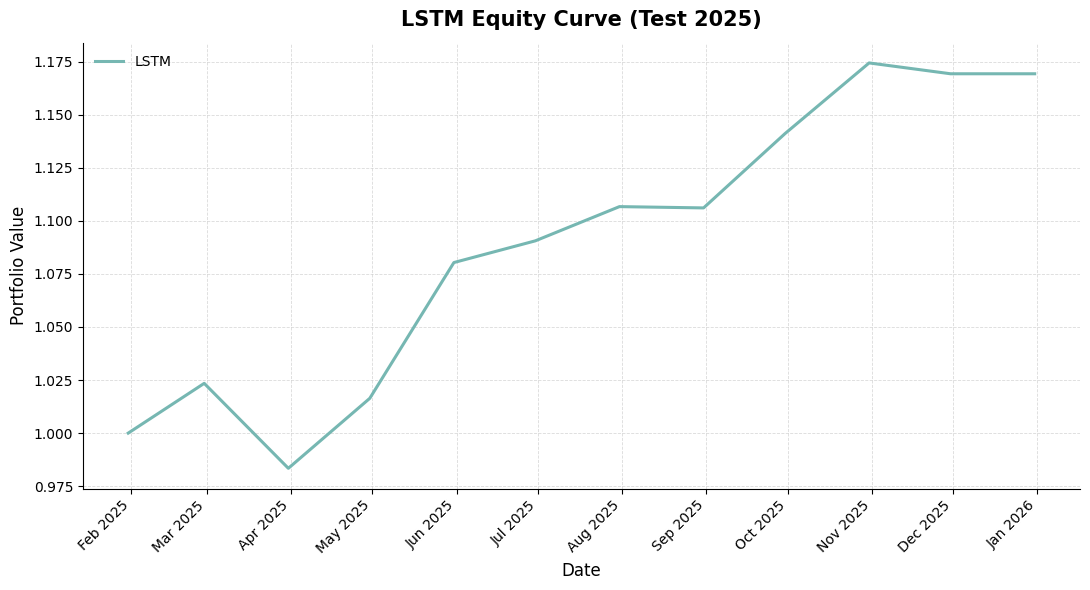

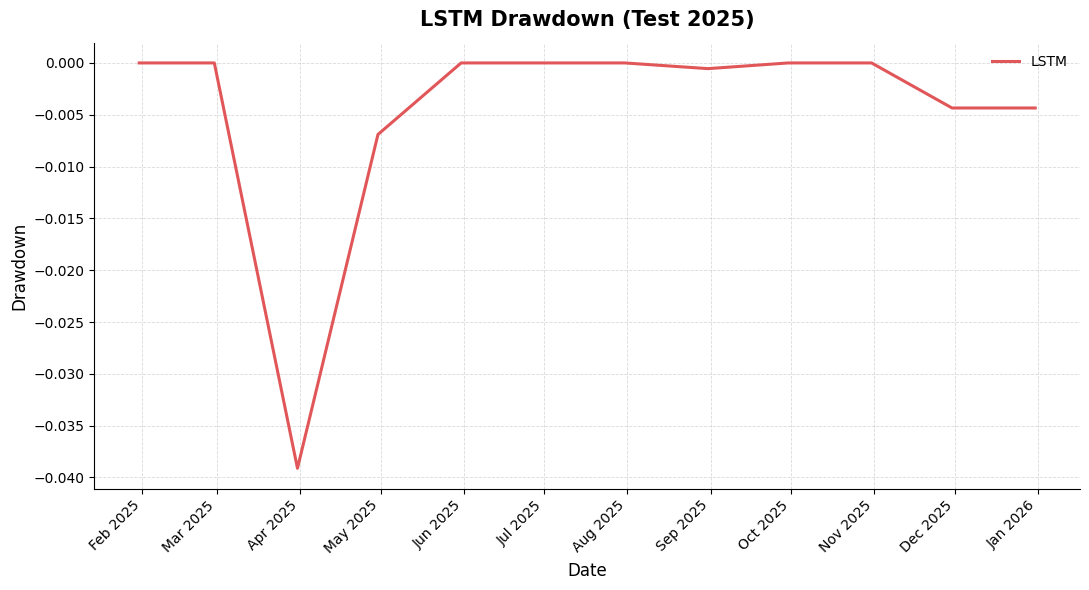

In [21]:
plot_equity_curve(
    lstm_results["equity_test"],
    title="LSTM Equity Curve (Test 2025)",
    save_path=fig_path("lstm_equity_test.png"),
    label="LSTM",
    color=get_model_color("lstm"),
    show=True,
)

plot_drawdown(
    lstm_results["equity_test"],
    title="LSTM Drawdown (Test 2025)",
    save_path=fig_path("lstm_drawdown_test.png"),
    label="LSTM",
    color="#E15759",
    show=True,
)

In [22]:
neural_test_summary = save_table(
    pd.DataFrame(
        [
            {
                "model": "MLP daily",
                **mlp_strategy_comparison[(mlp_strategy_comparison["model"] == "MLP daily") & (mlp_strategy_comparison["split"] == "test_2025")].iloc[0].to_dict(),
            },
            {
                "model": "MLP daily_ohlcv",
                **mlp_strategy_comparison[(mlp_strategy_comparison["model"] == "MLP daily_ohlcv") & (mlp_strategy_comparison["split"] == "test_2025")].iloc[0].to_dict(),
            },
            {
                "model": "LSTM",
                "split": "test_2025",
                **lstm_results["metrics_test"],
            },
        ]
    ),
    "neural_test_strategy_summary.csv",
    index=False,
)
neural_test_summary

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\neural_test_strategy_summary.csv


,model,split,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,MLP daily,test_2025,0.290920,0.290920,0.135754,-0.043890,1.961135,0.449761,0.473684,0.631579
1,MLP daily_ohlcv,test_2025,0.141031,0.141031,0.140191,-0.079659,1.009288,0.550239,0.578947,0.736842
2,LSTM,test_2025,0.169316,0.169316,0.088544,-0.039112,1.818267,0.672727,0.700000,0.900000


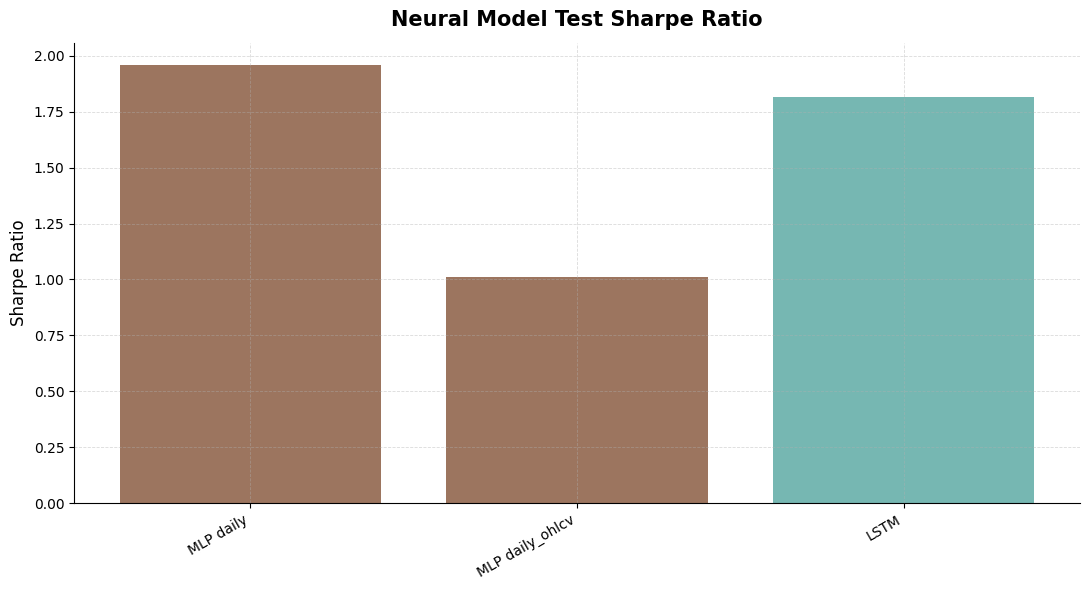

In [23]:
neural_test_sharpe = neural_test_summary.set_index("model")["sharpe_ratio"]

plot_metric_bar(
    neural_test_sharpe,
    title="Neural Model Test Sharpe Ratio",
    ylabel="Sharpe Ratio",
    color_map={
        "MLP daily": get_model_color("mlp"),
        "MLP daily_ohlcv": "#9C755F",
        "LSTM": get_model_color("lstm"),
    },
    save_path=fig_path("neural_test_sharpe_comparison.png"),
    show=True,
)

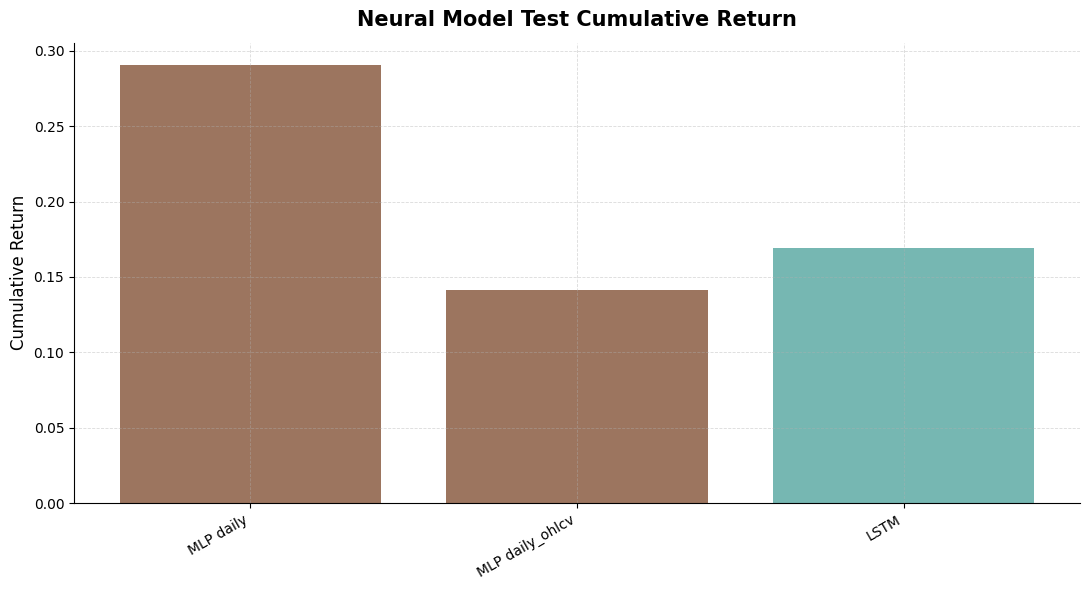

In [24]:
neural_test_cumret = neural_test_summary.set_index("model")["cumulative_return"]

plot_metric_bar(
    neural_test_cumret,
    title="Neural Model Test Cumulative Return",
    ylabel="Cumulative Return",
    color_map={
        "MLP daily": get_model_color("mlp"),
        "MLP daily_ohlcv": "#9C755F",
        "LSTM": get_model_color("lstm"),
    },
    save_path=fig_path("neural_test_cumulative_return_comparison.png"),
    show=True,
)

## 4. Interpretation

The neural models produced several important findings:

- neural architectures could be trained successfully  
- loss curves provided useful visibility into the fitting process  
- the MLP feature-source comparison did not produce a model that surpassed the best Random Forest  
- the LSTM sequence model also did not achieve superior out-of-sample ranking and portfolio performance  
- additional model flexibility alone was not sufficient to overcome the low signal-to-noise nature of monthly stock return prediction in this setup  

These results suggest that, in this project, robust tabular feature engineering combined with better generalization behavior was more effective than increasing neural-model complexity.

In [25]:
nn_findings = save_table(
    pd.DataFrame(
        {
            "finding": [
                "MLP and LSTM were evaluated with explicit training diagnostics",
                "Loss curves provided direct visibility into neural model fitting",
                "MLP daily and MLP daily_ohlcv formed a useful neural tabular comparison",
                "The LSTM sequence model did not outperform the final Random Forest model",
                "Neural models remained useful comparison models but were not selected as final models",
            ]
        }
    ),
    "nn_key_findings.csv",
    index=False,
)
nn_findings

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook07\nn_key_findings.csv


,finding
0,MLP and LSTM were evaluated with explicit trai...
1,Loss curves provided direct visibility into ne...
2,MLP daily and MLP daily_ohlcv formed a useful ...
3,The LSTM sequence model did not outperform the...
4,Neural models remained useful comparison model...


## 5. Final conclusion

The neural-model family provided an important test of whether more flexible nonlinear and sequence-based architectures could improve stock return prediction.

The notebook shows that:

- MLP and LSTM were trained and evaluated properly  
- loss curves were available as model-training diagnostics  
- neither model achieved superior out-of-sample ranking or portfolio performance relative to the final Random Forest model  

The next notebook brings all model families together in one final comparison and model-selection summary.